## Notebook to do as Lea said: check the correlation of the variant distance
- download the TSS and other annotations of each gene
- If you measure the distance of a variant to the TSS you might look also into upstream and downstram
- remove the version information from both data sources

In [3]:
10**6 * 0.05

50000.0

In [1]:
# import
import pandas as pd
import os
# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
import yaml
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()



In [2]:
# read the data

# gene information from biomart
gene_TSS_df = pd.read_csv(config['files']['final_design']['gene_meta_info'], sep="\t")

# mpralm results
mpralm_results = pd.read_csv(config['files']['creating']['mprasnakeflow_resequencing_count_minthreshold'], sep="\t")
mpra_metadata_info_path = '/home/kisa/coding/80K_MPRA/combined_info_results/bcMPRAlm_variants_predictions.tsv.gz'
mpralm_info_results = pd.read_csv(mpra_metadata_info_path, sep="\t")
mpralm_info_results['label'] = mpralm_info_results['variant_id'].apply(hf.get_label)
tested_mpralm_info_results = mpralm_info_results.loc[mpralm_info_results['variant_id'].str.contains('cardiac_neuro_cava_random')]


/tmp/ipykernel_25250/706628033.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  gene_TSS_df = pd.read_csv(config['files']['final_design']['gene_meta_info'], sep="\t")


In [3]:
mpralm_info_results.head()

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,label
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,26.678520,16.150892,343.479770,16.150892,343.479770,singleton,0.2112,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,3.230990,cardiac_neuro_cava_random
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,3.795257,11.369314,19.146544,11.369314,19.146544,rare,0.1749,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,12.338594,cardiac_neuro_cava_random
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,5.332857,0.763544,39.061070,0.763544,39.061070,singleton,0.3061,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,14.999283,cardiac_neuro_cava_random
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,21.589469,14.814480,26.345566,14.814480,26.345566,ultra-rare,0.1496,cardiac_neuro_cava_random:ATR|ENSG00000175054....,14.484218,cardiac_neuro_cava_random
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,1.717218,5.488126,110.387634,5.488126,110.387634,singleton,0.1550,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,4.657819,cardiac_neuro_cava_random


In [4]:
print(tested_mpralm_info_results.columns)
tested_mpralm_info_results.head()

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type,REF_DNASE:neural stem progenitor cell originated from H1-hESC,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC,label
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,26.678520,16.150892,343.479770,16.150892,343.479770,singleton,0.2112,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,3.230990,cardiac_neuro_cava_random
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,3.795257,11.369314,19.146544,11.369314,19.146544,rare,0.1749,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,12.338594,cardiac_neuro_cava_random
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,5.332857,0.763544,39.061070,0.763544,39.061070,singleton,0.3061,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,14.999283,cardiac_neuro_cava_random
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,21.589469,14.814480,26.345566,14.814480,26.345566,ultra-rare,0.1496,cardiac_neuro_cava_random:ATR|ENSG00000175054....,14.484218,cardiac_neuro_cava_random
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,1.717218,5.488126,110.387634,5.488126,110.387634,singleton,0.1550,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,4.657819,cardiac_neuro_cava_random


#### check for range of logFC after barcoode MPRAlm

In [5]:
tested_mpralm_info_results.variant_log2FC.describe()

count    36181.000000
mean        -0.003277
std          0.177148
min         -1.583897
25%         -0.100190
50%         -0.004309
75%          0.091517
max          1.531757
Name: variant_log2FC, dtype: float64

#### Investigate common variants for the meeting with Alice (10.06.2024)
- Number of common with significant effect
- Number of neuro specific, actionable and cardiac

In [6]:
def effect_direction(log2fc):
    return 'activating' if log2fc > 0 else 'repressing'

In [7]:
tested_mpralm_info_results['effect_direction'] = tested_mpralm_info_results['variant_log2FC'].apply(effect_direction)

In [8]:
significant_mpralm_results = tested_mpralm_info_results.loc[tested_mpralm_info_results['is_significant'] == 'yes']
significant_mpralm_results # 522
common_significant_mpralm_results = significant_mpralm_results.loc[significant_mpralm_results['variant_type'].isin(['common', 'rare'])]
common_significant_mpralm_results # 207
common_significant_mpralm_results['variant_type'].value_counts()
# variant_type
# common    109 >=5%
# rare       98 <5% >= 1%
common_significant_mpralm_results['gene_set_list'].value_counts()

# neuro_common_signifianct_mpralm_results
# tested_mpralm_info_results['variant_type']



['neuro']               127
['cardiac']              50
['cava']                 14
['random']                8
['cardiac', 'neuro']      6
['cardiac', 'cava']       2
Name: gene_set_list, dtype: int64

In [9]:
significant_mpralm_results['variant_type'].value_counts()

singleton     162
ultra-rare    153
common        109
rare           98
Name: variant_type, dtype: int64

#### Preprocess the mpralm dataframe
- get the ensemble id of the genes based on the ids


In [10]:
def identify_ensemble_id(header):
    # cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G => ENSG00000038382.23
    if not ('cardiac_neuro_cava_random' in header):
        print('ERROR: function not defined for this case')
        return -1
    pipe_split = header.split('|')
    if len(pipe_split) < 4:
        print('ERROR: function expects 3 pipe regions')
        return -1
    if not '.' in pipe_split[1]:
        print('ERROR: Expected to have a version number, do we have a special case here? ', pipe_split[1])
    return pipe_split[1]


def remove_version_from_id(gene_transcript_id):
    if '.' in gene_transcript_id:
        return gene_transcript_id.split('.')[0]
    else:
        print('No version number detected.')
        return gene_transcript_id

In [11]:
identify_ensemble_id('cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G')

'ENSG00000038382.23'

In [12]:
tested_mpralm_info_results.columns
tested_mpralm_info_results['variant_id'].to_list()
tested_mpralm_info_results['gene_stable_id_version'] = tested_mpralm_info_results['variant_id'].apply(identify_ensemble_id)
tested_mpralm_info_results['gene_stable_id'] = tested_mpralm_info_results['gene_stable_id_version'].apply(remove_version_from_id)
# tested_mpralm_info_results.drop(columns=['gene_stable_id_version'], inplace=True)

# variant_id

#### Preprocess the gene meta info 

In [13]:
# remove the version information (not needed, because we have version information in the headers)
# rename columns

renamed_columns = {'Transcription start site (TSS)': 'TSS', 'Gene stable ID version': 'gene_stable_id_version', 'Transcript stable ID version': 'transcript_stable_id_version', 'Chromosome/scaffold name': 'gene_chrom'}

gene_TSS_df = gene_TSS_df.rename(columns=renamed_columns)
gene_TSS_df['gene_stable_id'] = gene_TSS_df['gene_stable_id_version'].apply(remove_version_from_id)


# # investigate the chromosome info:
#gene_TSS_df['Chromosome/scaffold name'].value_counts()

# investigate if gene_stable_id is unique
if gene_TSS_df['gene_stable_id'].nunique() != gene_TSS_df.shape[0]:
    print('ERROR: gene stable id without version is not unique')
else:
    print('gene stable id without version is unique')

# investigate how many of the ids are matchable to the 80K data: expectation: all are matchable
mpralm_results.shape[0] # 205657

# create a bed tool out of gene id


gene stable id without version is unique


205657

### How many are matchable:
- without looking on the version number all of them are matchable


In [14]:
gene_TSS_df.head()
# tested_mpralm_info_results.head()

,gene_stable_id_version,transcript_stable_id_version,gene_chrom,TSS,Transcript length (including UTRs and CDS),Gene % GC content,Gene type,Transcript type,gene_stable_id
0,ENSG00000210049.1,ENST00000387314.1,MT,577,71,40.85,Mt_tRNA,Mt_tRNA,ENSG00000210049
1,ENSG00000211459.2,ENST00000389680.2,MT,648,954,45.49,Mt_rRNA,Mt_rRNA,ENSG00000211459
2,ENSG00000210077.1,ENST00000387342.1,MT,1602,69,42.03,Mt_tRNA,Mt_tRNA,ENSG00000210077
3,ENSG00000210082.2,ENST00000387347.2,MT,1671,1559,42.81,Mt_rRNA,Mt_rRNA,ENSG00000210082
4,ENSG00000209082.1,ENST00000386347.1,MT,3230,75,38.67,Mt_tRNA,Mt_tRNA,ENSG00000209082


In [15]:
tss_mpralm = tested_mpralm_info_results.merge(gene_TSS_df, on="gene_stable_id", how="left")
tss_mpralm.shape[0]

tss_mpralm.loc[tss_mpralm['TSS'].isna()]['variant_id'].to_list() # no missing

[]

### Make bed and sort them
- chrom, start, end [pos-1, pos]
- sorting based on chrom and start

In [16]:
# not sure if needed here
def from_var_pos_to_bed(chr_pos_ref_alt):
    '''
    Gets e.g. 14-123514-A-C and wants to get chr, start, end
    '''
    chromosome = chr_pos_ref_alt.split('-')[0]
    start = get_variant_0_based_start(chr_pos_ref_alt)
    end = get_variant_1_based_end(chr_pos_ref_alt)
    return chromosome, start, end


def get_chromosome(chr_pos_ref_alt):
    '''
    From e.g. 14-123514-A-C to 14
    '''
    return chr_pos_ref_alt.split('-')[0]


def get_variant_0_based_start(chr_pos_ref_alt):
    '''
    From e.g. 14-123514-A-C to 123513
    '''
    variant_pos_1_based = int(chr_pos_ref_alt.split('-')[1])
    return variant_pos_1_based - 1


def get_variant_1_based_end(chr_pos_ref_alt):
    '''
    From e.g. 14-123514-A-C to 123514
    '''
    return int(chr_pos_ref_alt.split('-')[1])

In [17]:
tested_mpralm_info_results['variant_position'] = tested_mpralm_info_results['chr_pos_ref_alt'].apply(get_variant_1_based_end)

In [18]:
mpralm_variant_bed = tested_mpralm_info_results[['variant_id', 'chr_pos_ref_alt']]


mpralm_variant_bed['chrom'] = mpralm_variant_bed['chr_pos_ref_alt'].apply(get_chromosome)
mpralm_variant_bed['chromStart'] = mpralm_variant_bed['chr_pos_ref_alt'].apply(get_variant_0_based_start)
mpralm_variant_bed['chromEnd'] = mpralm_variant_bed['chr_pos_ref_alt'].apply(get_variant_1_based_end)
mpralm_variant_bed.rename(columns={'variant_id': 'name'}, inplace=True)
mpralm_variant_bed = mpralm_variant_bed[['chrom', 'chromStart', 'chromEnd', 'name']]
mpralm_variant_bed = mpralm_variant_bed.sort_values(by=['chrom', 'chromStart', 'chromEnd'])
# write to file
output_path = '/home/kisa/coding/80K_MPRA/info/gene_info_tss_gc_content'
# mpralm_variant_bed.to_csv(os.path.join(output_path, 'barcode_MPRAlm_variant_sorted.bed'), sep="\t", index=None)

/tmp/ipykernel_25250/1464708033.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpralm_variant_bed['chrom'] = mpralm_variant_bed['chr_pos_ref_alt'].apply(get_chromosome)
/tmp/ipykernel_25250/1464708033.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpralm_variant_bed['chromStart'] = mpralm_variant_bed['chr_pos_ref_alt'].apply(get_variant_0_based_start)
/tmp/ipykernel_25250/1464708033.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

### Biomart: Compute the distance of the variant and the associated gene
1. Merge variant and gene bed 
2. Compute distance as | variant position - TSS position | 
3. Compute is upstream: yes if TSS position > Variant position else no

In [19]:
tss_mpralm.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

add the distance to gene and is_upstream column and remove unused columns

In [20]:
tss_mpralm

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,gene_stable_id_version_x,gene_stable_id,gene_stable_id_version_y,transcript_stable_id_version,gene_chrom,TSS,Transcript length (including UTRs and CDS),Gene % GC content,Gene type,Transcript type
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,ENSG00000038382.23,ENSG00000038382,ENSG00000038382.23,ENST00000344204.9,5,14143342,11460,43.38,protein_coding,protein_coding
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,ENSG00000038382.23,ENSG00000038382,ENSG00000038382.23,ENST00000344204.9,5,14143342,11460,43.38,protein_coding,protein_coding
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,ENSG00000163516.14,ENSG00000163516,ENSG00000163516.14,ENST00000323348.10,2,219229806,2540,49.05,protein_coding,protein_coding
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,ENSG00000175054.16,ENSG00000175054,ENSG00000175054.16,ENST00000350721.9,3,142578733,8158,37.11,protein_coding,protein_coding
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,ENSG00000039068.20,ENSG00000039068,ENSG00000039068.20,ENST00000261769.10,16,68737292,4811,46.88,protein_coding,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36176,-0.000170,-0.383716,-0.002306,9.981607e-01,9.993533e-01,-6.829957,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,Region=TMEM70|ENSG00000175606.11|EH38E3840361_...,0.000007,1.0,...,ENSG00000175606.11,ENSG00000175606,ENSG00000175606.11,ENST00000312184.6,8,73976195,2032,43.80,protein_coding,protein_coding
36177,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,Region=CHD7|ENSG00000171316.14|EH38E3836279_fw...,0.021523,3273.0,...,ENSG00000171316.14,ENSG00000171316,ENSG00000171316.14,ENST00000423902.7,8,60678740,11606,39.99,protein_coding,protein_coding
36178,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,ENSG00000136574.19,ENSG00000136574,ENSG00000136574.19,ENST00000532059.6,8,11704202,3419,48.32,protein_coding,protein_coding
36179,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,ENSG00000136574.19,ENSG00000136574,ENSG00000136574.19,ENST00000532059.6,8,11704202,3419,48.32,protein_coding,protein_coding


In [21]:
# duplicated (see below) I think this can be removed, or is it still used?
def check_same_chromosome(row, headers=['Chromosome/scaffold name', 'variant_chrom']):
    """
    Check if given headers are same:
    """
    chrom_one = row[headers[0]]
    chrom_two = row[headers[1]]

    if chrom_one != chrom_two:
        print('Something unexpected happend', chrom_one, chrom_two)
        return False
    return True



In [42]:
tss_mpralm['gene_chrom'] = tss_mpralm['gene_chrom'].apply(str)
tss_mpralm['variant_chrom'] = tss_mpralm['chr_pos_ref_alt'].apply(get_chromosome)

# sanity checking if all on same chromosome
tss_mpralm.apply(lambda x: check_same_chromosome(x, ['gene_chrom', 'variant_chrom']), axis=1).sum() # expected: 36181

# get variant position:
tss_mpralm['variant_position'] = tss_mpralm['chr_pos_ref_alt'].apply(get_variant_1_based_end)
# TODO Check if TSS is 1 based or 0 based?


# compute distance
# tss_mpralm['variant_gene_distance'] = tss_mpralm.apply(lambda row: get_variant_gene_TSS_distance(row, TSS_position='TSS', variant_position='variant_position'), axis=1)

# is variant upstream?
# tss_mpralm['variant_is_upstream'] = tss_mpralm.apply(lambda row: is_variant_upstream(row, TSS_position='TSS', variant_position='variant_position'), axis=1)

# TODO: For kaltik: is variant in alternative UTR?

# remove unused columns

In [ ]:
tss_mpralm['variant_is_upstream'].value_counts()

variant_is_upstream
no    36181
Name: count, dtype: int64

##### Huge distances in resulting table (2x10^6) expected: up to 100kb

In [ ]:
tss_mpralm['variant_gene_distance'].describe() # maximum is 2x10^6? it should be something between 1 and 100k?
tss_mpralm['variant_gene_distance'].max()

# get all odd cases
tss_mpralm.loc[tss_mpralm['variant_gene_distance'] > 100000].sort_values(by='variant_gene_distance').tail()
# 11183 have a higher distance than 100000

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,gene_chrom,TSS,Transcript length (including UTRs and CDS),Gene % GC content,Gene type,Transcript type,variant_chrom,variant_position,variant_gene_distance,variant_is_upstream
9763,-0.178459,-0.815059,-1.294551,0.196268,0.736137,-5.435101,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929556_rev...,0.000018,2.0,...,X,33211549,13992,36.42,protein_coding,protein_coding,X,31115645,2095904,no
22646,-0.087455,0.296054,-0.806550,0.420356,0.868398,-6.074880,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929553_rev...,0.000071,8.0,...,X,33211549,13992,36.42,protein_coding,protein_coding,X,31101802,2109747,no
18695,-0.107122,0.282806,-1.020906,0.307825,0.817498,-5.920068,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929553_rev...,0.000009,1.0,...,X,33211549,13992,36.42,protein_coding,protein_coding,X,31101714,2109835,no
5178,0.241784,-0.205373,1.742011,0.082336,0.578617,-4.800758,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E1035031_rev...,0.000054,6.0,...,X,33211549,13992,36.42,protein_coding,protein_coding,X,31099483,2112066,no
18818,-0.004411,-0.133079,-0.021745,0.982669,0.996055,-5.925059,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929552_rev...,0.011303,1269.0,...,X,33211549,13992,36.42,protein_coding,protein_coding,X,31098567,2112982,no


In [ ]:
# example:
14408059 - 14143342


# example: DMD|ENSG00000198947.18
# https://grch37.ensembl.org/Homo_sapiens/Gene/Summary?db=core;g=ENSG00000198947;r=X:31115794-33357558

264717

### Gencode v42: 
Compute the distance of the variant and the associated gene
1. Merge variant and gene bed 
2. Compute distance as | variant position - TSS position | 
3. Compute is upstream: if gene on + strand => yes if TSS position > Variant position else no
    - else: 'yes' if TSS position < variant position else 'no'

##### Using awk scripts from MPRA_design workflow (genes.smk)

In [ ]:
# from gtf to bed like file of TSSs
"""
zcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.annotation.gtf.gz | \
awk '$3 == "transcript"' | \
sed 's/^chr//' | \
awk -v "OFS=\\t" '{{start = $4; if ($7 == "-"){{start = $5}}; print $1,start-1,start,$16"|"$10,".",$7}}' | \
sed 's/[\\";]//g' | \
sort -k1,1 -k2,2n | \
bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.log
"""

'\nzcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.annotation.gtf.gz | awk \'$3 == "transcript"\' | sed \'s/^chr//\' | awk -v "OFS=\\t" \'{{start = $4; if ($7 == "-"){{start = $5}}; print $1,start-1,start,$16"|"$10,".",$7}}\' | sed \'s/[\\";]//g\' | sort -k1,1 -k2,2n | bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.log\n'

In [ ]:
# from bed of multiple tss per gene to one region of left most and right most tss
"""
zcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz | \
sort -k4,4 -k1,1 -k 2,2n | \
awk -v "OFS=\\t" 'BEGIN {{
    id="";chr="";start="";end="";strand=""
}}{{
    if ($4 == id) {{
        end=$3
    }} else {{
        if (NR > 1) {{
            print chr,start,end,id,".",strand;
        }};
        id=$4;chr=$1;start=$2;end=$3;strand=$6;
    }}
}} END {{
    print chr,start,end,id,".",strand
}}' | \
sort -k1,1 -k2,2n | \
bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.log
"""

'\nzcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.bed.gz | sort -k4,4 -k1,1 -k 2,2n | awk -v "OFS=\\t" \'BEGIN {{\n    id="";chr="";start="";end="";strand=""\n}}{{\n    if ($4 == id) {{\n        end=$3\n    }} else {{\n        if (NR > 1) {{\n            print chr,start,end,id,".",strand;\n        }};\n        id=$4;chr=$1;start=$2;end=$3;strand=$6;\n    }}\n}} END {{\n    print chr,start,end,id,".",strand\n}}\' | sort -k1,1 -k2,2n | bgzip -c > /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.bed.gz 2> /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.log\n'

##### Using bedtools (not so useful)
- 12.06: with bedtools I dont get for every variant a closest region (number of rows of resulting bed file is smaller than the number of rows for the initial variant bed file)
- alternatively manually map the variant and the TSS-regions by associated gene id (expectation it should be unique?)

In [ ]:
# use bedtools closest

In [ ]:
"""bedtools closest -a /home/kisa/coding/80K_MPRA/info/gene_info_tss_gc_content/barcode_MPRAlm_variant_sorted.bed -b /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.bed.gz"""

'bedtools closest -a /home/kisa/coding/80K_MPRA/info/gene_info_tss_gc_content/barcode_MPRAlm_variant_sorted.bed -b /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.bed.gz'

#### Manually mapping variants to TSS-region bed

In [29]:
collapsed_tss_regions = pd.read_csv(config['files']['creating']['collapsed_transcripts_v42'], sep="\t", header=None)
collapsed_tss_regions.columns = ['chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand']
collapsed_tss_regions
# ['chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand']

,chrom,chromStart,chromEnd,name,score,strand
0,1,11868,11869,DDX11L2|ENSG00000290825.1,.,+
1,1,12009,12010,DDX11L1|ENSG00000223972.6,.,+
2,1,17435,17436,MIR6859-1|ENSG00000278267.1,.,-
3,1,29553,30267,MIR1302-2HG|ENSG00000243485.5,.,+
4,1,29569,29570,WASH7P|ENSG00000227232.5,.,-
...,...,...,...,...,...,...
62691,Y,57184215,57192634,IL9R|ENSG00000124334.18_PAR_Y,.,+
62692,Y,57190737,57190738,ENSG00000270726|ENSG00000270726.6_PAR_Y,.,+
62693,Y,57203356,57203357,WASIR1|ENSG00000185203.12_PAR_Y,.,-
62694,Y,57207345,57210591,WASH6P|ENSG00000182484.15_PAR_Y,.,+


In [30]:
tested_mpralm_info_results.columns # gene_stable_id_version

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

##### Preprocess tss regions: 
- Add gene id as column

In [31]:
import re


# sanity checking
def tss_start_smaller_than_tss_end(row):
    if row['chromEnd'] < row['chromStart']:
        print(row)
        return False
    return True


def get_ensembl_id(name):
    """Get the ensembl id from the name e.g. isolate the ensemble id from the collapsed tss regions"""
    ensembl_id = re.search('[A-Z]{4}[\d]*\.([0-9]*)', name)
    return ensembl_id.group()


def remove_version_ensembl_id(ensembl_id):
    if "." in ensembl_id:
        return ensembl_id.split(".")[0]
    else:
        print('Provided ensemble id ', ensembl_id, ' does not have a version tag')
        return ensembl_id


def get_variant_gene_TSS_distance(row, TSS_start, TSS_end, variant_position):
    """
    Compute distance between TSS and variant position
    """
    return min(abs(row[TSS_start] - row[variant_position]), abs(row[TSS_end] - row[variant_position]))



def is_variant_upstream(row, TSS_start, TSS_end, strand, variant_position):
    """
    Return if variant is upstream ('yes') based on TSS position and variant position and return ('inbetween') if between TSS start and end
    Logic:
    1) if + strand: variant position < tss start=> 'upstream', elif variant position > tss end => downstream else: inbetween
    2) if - strand; variant position < tss start=> 'downstream', elif variant position > tss end => upstream else: inbetween
    """
    if (row[TSS_start] < row[variant_position]) and (row[TSS_end] > row[variant_position]):
        return 'Within left most and right most TSS'
    if row[strand] == "+":
        return 'upstream' if row[TSS_start] > row[variant_position] else 'downstream'
    elif row[strand] == "-":
        return 'downstream' if row[TSS_start] > row[variant_position] else 'upstream'


In [38]:
collapsed_tss_regions.columns

Index(['chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand',
       'gene_stable_id_version'],
      dtype='object')

In [39]:
collapsed_tss_regions['gene_stable_id_version'] = collapsed_tss_regions['name'].apply(get_ensembl_id)

# are the gene_stable ids unique?

collapsed_tss_regions['gene_stable_id_version'].nunique() # 58696 => no (62696 length) => 62649


62649

In [34]:
collapsed_tss_regions.strand.value_counts()

+    31807
-    30889
Name: strand, dtype: int64

Investigate if chromStart of TSS needs to be smaller than chromEnd of TSS for every case

In [35]:
collapsed_tss_regions.apply(tss_start_smaller_than_tss_end, axis=1).sum()

62696

Use strand information in order to check for upstram and downstream variants

In [36]:

variant_tss_regions['variant_position_type'] = variant_tss_regions.apply(lambda row: is_variant_upstream(row, TSS_start='chromStart', TSS_end='chromEnd', strand='strand', variant_position='variant_position'), axis=1)
variant_tss_regions['variant_position_type'].value_counts()
# inbetween     17930
# downstream     9160
# upstream       9091
# variant_tss_regions['variant_is_upstream'] = variant_tss_regions.apply(lambda row: is_variant_upstream(row, TSS_position='TSS', variant_position='variant_position'), axis=1)

NameError: name 'variant_tss_regions' is not defined

In [38]:
variant_tss_regions

NameError: name 'variant_tss_regions' is not defined

/tmp/ipykernel_489371/1872020678.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Category', data=df, palette='pastel')


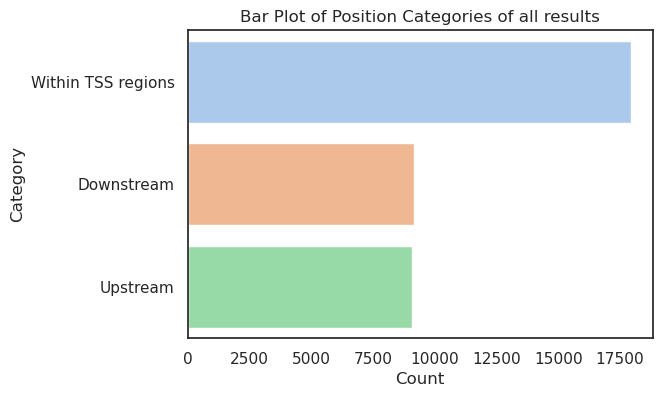

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame with your data
data = {
    'Category': ['Within TSS regions', 'Downstream', 'Upstream'],
    'Value': [17930, 9160, 9091],

}
df = pd.DataFrame(data)

# Set seaborn plotting aesthetics
sns.set(style='white')

# Create a bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x='Value', y='Category', data=df, palette='pastel')

# Add labels and title
plt.xlabel('Count')
plt.ylabel('Category')
plt.title('Bar Plot of Position Categories of all results')

# Show the plot
plt.show()


Add significant composition to this

In [137]:
variant_tss_regions.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

In [142]:
variant_tss_regions.groupby(['is_significant', 'variant_position_type']).size()

is_significant  variant_position_type
no              downstream                9024
                inbetween                17670
                upstream                  8965
yes             downstream                 136
                inbetween                  260
                upstream                   126
dtype: int64

/tmp/ipykernel_489371/3436387237.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Category', data=df, palette='pastel')


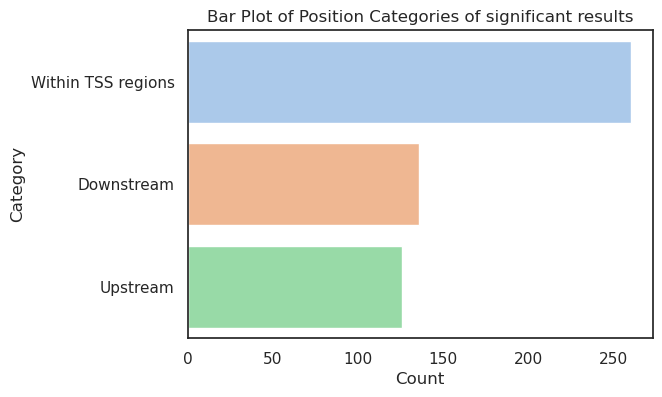

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame with your data
data = {
    'Category': ['Within TSS regions', 'Downstream', 'Upstream'],
    'Value': [260, 136, 126],

}
df = pd.DataFrame(data)

# Set seaborn plotting aesthetics
sns.set(style='white')

# Create a bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x='Value', y='Category', data=df, palette='pastel')

# Add labels and title
plt.xlabel('Count')
plt.ylabel('Category')
plt.title('Bar Plot of Position Categories of significant results')

# Show the plot
plt.show()


##### computing the distance
- distance between TSS and variant

In [147]:
variant_tss_regions['tss_region_variant_distance'] = variant_tss_regions.apply(lambda row: get_variant_gene_TSS_distance(row, TSS_start='chromStart', TSS_end='chromEnd', variant_position='variant_position'), axis=1)


In [149]:
1.445326e+05

144532.6

In [150]:
4.900000e+01

49.0

In [151]:
1.547730e+05

154773.0

In [148]:
variant_tss_regions['tss_region_variant_distance'].describe()

count    3.618100e+04
mean     1.445326e+05
std      2.303593e+05
min      4.900000e+01
25%      2.436500e+04
50%      4.881000e+04
75%      1.547730e+05
max      2.204287e+06
Name: tss_region_variant_distance, dtype: float64

(0.0, 1000000.0)

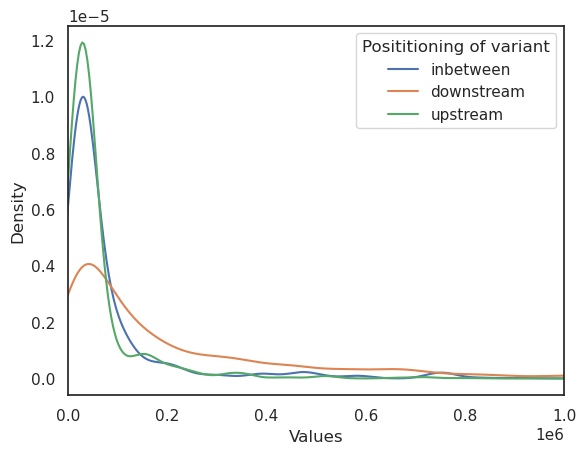

In [154]:
import matplotlib.pyplot as plt

variant_tss_regions.groupby('variant_position_type')['tss_region_variant_distance'].plot(kind='kde')
plt.legend(variant_tss_regions['variant_position_type'].unique(), title='Posititioning of variant')
plt.xlabel('Distance of Variant to closest TSS')
plt.xlim(0,1*10**6)

Investigate how many cases are above expectation

In [152]:
variant_tss_regions[variant_tss_regions['tss_region_variant_distance'] > 50000] # 17569

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,gene_stable_id,variant_position,chrom,chromStart,chromEnd,name,score,strand,variant_position_type,tss_region_variant_distance
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,ENSG00000038382,14408059,5,14143341,14498516,TRIO|ENSG00000038382.23,.,+,inbetween,264718
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,ENSG00000038382,14259916,5,14143341,14498516,TRIO|ENSG00000038382.23,.,+,inbetween,116575
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,ENSG00000175054,142578095,3,142453165,142578733,ATR|ENSG00000175054.16,.,-,inbetween,124930
5,-0.812880,0.765608,-11.507714,1.550103e-28,9.479916e-25,53.885095,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,ENSG00000038382,14408083,5,14143341,14498516,TRIO|ENSG00000038382.23,.,+,inbetween,264742
7,-1.141630,-0.187319,-11.244028,8.433980e-27,3.868456e-23,49.669666,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,Region=RAD51B|ENSG00000182185.19|EH38E3101219_...,0.000230,35.0,...,ENSG00000182185,68160488,14,67819778,68545562,RAD51B|ENSG00000182185.19,.,+,inbetween,340710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36175,0.000845,-0.069064,0.012114,9.903371e-01,9.977055e-01,-6.829936,cardiac_neuro_cava_random:NCOA1|ENSG0000008467...,Region=NCOA1|ENSG00000084676.16|EH38E1980646_f...,0.891901,135667.0,...,ENSG00000084676,24584664,2,24491253,24767771,NCOA1|ENSG00000084676.16,.,+,inbetween,93411
36177,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,Region=CHD7|ENSG00000171316.14|EH38E3836279_fw...,0.021523,3273.0,...,ENSG00000171316,60777684,8,60678739,60862550,CHD7|ENSG00000171316.14,.,+,inbetween,98945
36178,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,ENSG00000136574,11806038,8,11676958,11756493,GATA4|ENSG00000136574.19,.,+,downstream,129080
36179,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,ENSG00000136574,11806038,8,11676958,11756493,GATA4|ENSG00000136574.19,.,+,downstream,129080


#### How huge are the designed ranges per gene? 
- how distant are chromStart and chromEnd of the tss regions?

In [24]:
def compute_tss_region_range(row, start, end):
    """
    Compute the distance between tss start and tss end => How huge are the inbetween ranges?
    """
    return abs(row[end] - row[start])

##### Make the analysis if the tss regions have high distances again from scratch (workflow results (right tss regions))
- sanity check for one example (ENSG00000230021.10: distance between chromStart and chromEnd: 239344)
1. 

In [25]:
# load workflow results and check the differences
collapsed_tss_regions = pd.read_csv('/home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.transcripts.collapsed.bed.gz', sep="\t", header=None)
collapsed_tss_regions.columns = ['chr', 'chromStart', 'chromEnd', 'name', 'score', 'strand']

collapsed_tss_regions['distance'] = collapsed_tss_regions.apply(lambda row: compute_tss_region_range(row, 'chromStart', 'chromEnd'), axis=1)

In [37]:
collapsed_tss_regions['distance'].describe()


# collapsed_tss_regions.loc[collapsed_tss_regions['distance'] > 1000000] # 2.000000e+06
collapsed_tss_regions.loc[collapsed_tss_regions['name'].str.contains('ENSG00000038382')] # 2.000000e+06

# # boxplot of the distances
# import seaborn as sns
# sns.boxplot(collapsed_tss_regions['distance'])

# collapsed_tss_regions.shape[0] # 62649

# awk command to check if thrid column is == 'transcript'
# zcat /home/kisa/coding/80K_MPRA/gencode_v42/gencode.v42.annotation.gtf.gz
# awk '$3 == "transcript"' | wc -l # 62649


,chr,chromStart,chromEnd,name,score,strand,distance
45483,5,14143341,14498516,TRIO|ENSG00000038382.23,.,+,355175


In [1]:
# variant_tss_regions['tss_region_range'] = variant_tss_regions.apply(lambda row: compute_tss_region_range(row, 'chromStart', 'chromEnd'), axis=1)

# variant_tss_regions['tss_region_range'].describe()
# variant_tss_regions['tss_region_range'].plot(kind='kde')

# variant_tss_regions.groupby('variant_position_type')['tss_region_range'].plot(kind='kde')
# plt.legend(variant_tss_regions['variant_position_type'].unique(), title='Posititioning of variant')
# plt.xlabel('Distance between left most and right most TSS')
# plt.xlim(0,1*10**6)

Investigate extreme ranges: 
- Below 10 

In [ ]:
variant_tss_regions

Found variants which do not match to any region (unsing version because of bug in the function)

In [40]:
# match variants and tss regions

variant_tss_regions = tested_mpralm_info_results.merge(collapsed_tss_regions, on='gene_stable_id_version', how='left')
variant_tss_regions.shape[0] # 36181
variant_tss_regions[variant_tss_regions['chromStart'].isna()] # no missing
# still upstream and downstream?

# is variant upstream?
variant_tss_regions['variant_is_upstream'] = variant_tss_regions.apply(lambda row: is_variant_upstream(row, TSS_position='TSS', variant_position='variant_position'), axis=1)

# compute distance
variant_tss_regions['variant_gene_distance'] = variant_tss_regions.apply(lambda row: get_variant_gene_TSS_distance(row, TSS_position='TSS', variant_position='variant_position'), axis=1)
variant_tss_regions.columns
variant_tss_regions.dtypes

TypeError: is_variant_upstream() got an unexpected keyword argument 'TSS_position'

In [ ]:
Hassan, Ali;Kircher, Martin;Beate.Emcken@uksh.de;Pia.Keukeleire@uksh.de;orazio.catona@uksh.de;Dash, Pyaree Mohan;Schubach, Max;anna.broschke@student.uni-luebeck.de;sudharsanagasc@gmail.com;Varun.Sreenivasan@uksh.de;Saranya.Balachandran@uksh.de;Nazaretyan, Lusiné;Salomon, Kilian


##### Older try with python

In [35]:
import pandas as pd
import gff2bed
gencode_gtf_path = config['files']['creating']['gene_gencode_v42']
gencode_gtf_data = pd.read_csv(config['files']['creating']['gene_gencode_v42'], header=None, sep="\t", comment="#")
gencode_gtf_data.head()

,0,1,2,3,4,5,6,7,8
0,chr1,HAVANA,gene,11869,14409,.,+,.,"gene_id ""ENSG00000290825.1""; gene_type ""lncRNA..."
1,chr1,HAVANA,transcript,11869,14409,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
2,chr1,HAVANA,exon,11869,12227,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
3,chr1,HAVANA,exon,12613,12721,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
4,chr1,HAVANA,exon,13221,14409,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."


In [ ]:
gencode_gtf_data.columns = ['chrom', 'source', 'feature_type', 'chromStart', 'chromEnd', 'score', 'strand', 'phase', 'gene_INFO']
gencode_gtf_data.head()

,chrom,source,feature_type,chromStart,chromEnd,score,strand,phase,gene_INFO
0,chr1,HAVANA,gene,11869,14409,.,+,.,"gene_id ""ENSG00000290825.1""; gene_type ""lncRNA..."
1,chr1,HAVANA,transcript,11869,14409,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
2,chr1,HAVANA,exon,11869,12227,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
3,chr1,HAVANA,exon,12613,12721,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."
4,chr1,HAVANA,exon,13221,14409,.,+,.,"gene_id ""ENSG00000290825.1""; transcript_id ""EN..."


In [ ]:
gencode_gtf_data.shape[0] # 3x10^6 features


3413841

##### Preprocess gencode gene file

In [ ]:
def get_gene_id(info_dict):
    """return gene_id from info dict"""
    if "gene_id" in info_dict.keys():
        return info_dict['gene_id']
    else:
        print('Unexpected case: gene_id not in info_dict')
        return -1

def get_gene_type(info_dict):
    """return gene_type from info dict"""
    if "gene_type" in info_dict.keys():
        return info_dict['gene_type']
    else:
        print('Unexpected case: gene_type not in info_dict')
        return -1

def get_gene_name(info_dict):
    """return gene_name from info dict"""
    if "gene_name" in info_dict.keys():
        return info_dict['gene_name']
    else:
        print('Unexpected case: gene_name not in info_dict')
        return -1


def isolate_chrom(chrom):
    """chr<num> or chrM, chrX, chrY => <num> or X, Y"""
    return chrom.split('chr')[1]

In [ ]:
# only transcript
transcripts_gencode_gtf = gencode_gtf_data.loc[gencode_gtf_data['feature_type'] == 'transcript'] # 252416

In [ ]:
# get gene_id as additional column
transcripts_gencode_gtf['gene_id'] = transcripts_gencode_gtf['gene_INFO'].apply(get_gene_id)
transcripts_gencode_gtf['gene_type'] = transcripts_gencode_gtf['gene_INFO'].apply(get_gene_type)
transcripts_gencode_gtf['gene_name'] = transcripts_gencode_gtf['gene_INFO'].apply(get_gene_name)
transcripts_gencode_gtf['chrom'] = transcripts_gencode_gtf['chrom'].apply(isolate_chrom)

AttributeError: 'str' object has no attribute 'keys'

In [ ]:
[x for x in gencode_gff_data['gene_type'].unique() if 'trans' in x]

['transcribed_unprocessed_pseudogene',
 'transcribed_processed_pseudogene',
 'transcribed_unitary_pseudogene',
 'translated_processed_pseudogene',
 'translated_unprocessed_pseudogene']

In [ ]:
gencode_gff_data['gene_INFO'].to_list()[0]

{'ID': 'ENSG00000290825.1',
 'gene_id': 'ENSG00000290825.1',
 'gene_type': 'lncRNA',
 'gene_name': 'DDX11L2',
 'level': '2',
 'tag': 'overlaps_pseudogene'}

In [ ]:
gencode_gff_data.head()

,chrom,chromStart,chromEnd,strand,gene_INFO,gene_id,gene_type,gene_name
0,1,11869,14409,+,"{'ID': 'ENSG00000290825.1', 'gene_id': 'ENSG00...",ENSG00000290825.1,lncRNA,DDX11L2
1,1,12010,13670,+,"{'ID': 'ENSG00000223972.6', 'gene_id': 'ENSG00...",ENSG00000223972.6,transcribed_unprocessed_pseudogene,DDX11L1
2,1,14404,29570,-,"{'ID': 'ENSG00000227232.5', 'gene_id': 'ENSG00...",ENSG00000227232.5,unprocessed_pseudogene,WASH7P
3,1,17369,17436,-,"{'ID': 'ENSG00000278267.1', 'gene_id': 'ENSG00...",ENSG00000278267.1,miRNA,MIR6859-1
4,1,29554,31109,+,"{'ID': 'ENSG00000243485.5', 'gene_id': 'ENSG00...",ENSG00000243485.5,lncRNA,MIR1302-2HG


##### Check the different types of gene_types

In [ ]:
gencode_gff_data.gene_type.value_counts() # top 3: protein_coding (20k), lncRNA (18k), processed_peudogene (10k)

gene_type
protein_coding                        20030
lncRNA                                18879
processed_pseudogene                  10149
unprocessed_pseudogene                 2607
misc_RNA                               2212
snRNA                                  1901
miRNA                                  1879
TEC                                    1054
transcribed_unprocessed_pseudogene      961
snoRNA                                  942
transcribed_processed_pseudogene        512
rRNA_pseudogene                         497
IG_V_pseudogene                         187
transcribed_unitary_pseudogene          153
IG_V_gene                               145
TR_V_gene                               107
unitary_pseudogene                       99
TR_J_gene                                79
scaRNA                                   49
rRNA                                     47
IG_D_gene                                37
TR_V_pseudogene                          33
Mt_tRNA               

##### Combine bc_mpralm and gene info and compute distance
- combine with version (nothing missing)

In [ ]:
def check_same_chromosome(row, headers=['Chromosome/scaffold name', 'variant_chrom']):
    """
    Check if given headers are same:
    """
    chrom_one = row[headers[0]]
    chrom_two = row[headers[1]]

    if chrom_one != chrom_two:
        print('Something unexpected happend', chrom_one, chrom_two)
        return False
    return True


def get_variant_gene_TSS_distance(row, TSS_position, variant_position):
    """
    Compute distance between TSS and variant position
    """
    return abs(row[TSS_position] - row[variant_position])


def is_variant_upstream(row, TSS_position, variant_position):
    """
    Return if variant is upstream ('yes') based on TSS position and variant position
    """
    return 'yes' if TSS_position >= variant_position else 'no'


def get_variant_1_based_end(chr_pos_ref_alt):
    '''
    From e.g. 14-123514-A-C to 123514
    '''
    return int(chr_pos_ref_alt.split('-')[1])


def get_chromosome(chr_pos_ref_alt):
    '''
    From e.g. 14-123514-A-C to 14
    '''
    return chr_pos_ref_alt.split('-')[0]

In [ ]:
tss_mpralm = tested_mpralm_info_results.merge(gencode_gff_data, left_on="gene_stable_id_version", right_on="gene_id", how="left")

Check for missing and the shape (sanity check)

In [ ]:
print(tss_mpralm.shape[0])
tss_mpralm.loc[tss_mpralm['gene_type'].isna()]

36181


,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,gene_stable_id_version,gene_stable_id,chrom,chromStart,chromEnd,strand,gene_INFO,gene_id,gene_type,gene_name


In [ ]:
tss_mpralm.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

Now compute distance between genes start and variant position

In [ ]:
# get variant position:
tss_mpralm['variant_position'] = tss_mpralm['chr_pos_ref_alt'].apply(get_variant_1_based_end)
tss_mpralm['variant_chrom'] = tss_mpralm['chr_pos_ref_alt'].apply(get_chromosome)

# get variant chrom


In [ ]:
# sanity check (same chromosome) if 36181 => all fine; if you see output => something needs to be fixed
tss_mpralm.apply(lambda row: check_same_chromosome(row, ['chrom', 'variant_chrom']), axis=1).sum()

36181

In [ ]:
tss_mpralm['gene_variant_distance'] = tss_mpralm.apply(lambda row: get_variant_gene_TSS_distance(row, 'chromStart', 'variant_position'), axis=1)

In [ ]:
tss_mpralm['gene_variant_distance'].describe()

count    3.618100e+04
mean     1.549554e+05
std      2.398874e+05
min      1.100000e+01
25%      2.602900e+04
50%      5.731800e+04
75%      1.729070e+05
max      2.233406e+06
Name: gene_variant_distance, dtype: float64

In [ ]:
tss_mpralm.loc[tss_mpralm['gene_id'] == 'ENSG00000198947.18']

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,chromStart,chromEnd,strand,gene_INFO,gene_id,gene_type,gene_name,variant_position,variant_chrom,gene_variant_distance
33,1.531757,1.375703,8.438583,2.376486e-15,2.725087e-12,23.109851,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929714_rev...,0.000009,1.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,31863206,X,765529
147,1.087067,0.971223,5.339832,2.257798e-07,5.698787e-05,6.459537,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929714_rev...,0.000062,7.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,31863212,X,765535
600,0.428980,-0.131663,3.258537,1.226011e-03,7.314998e-02,-1.184585,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929730_rev...,0.012599,1406.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,31965215,X,867538
743,-0.383917,-0.676888,-3.103130,2.033432e-03,1.026338e-01,-1.760734,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E2748617_rev...,0.019982,2241.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,31397251,X,299574
751,-0.300163,-0.131744,-3.138926,1.777887e-03,9.279912e-02,-1.780462,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929800_rev...,0.002058,231.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,33027046,X,1929369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35756,0.010686,-0.374528,0.133078,8.941641e-01,9.864362e-01,-6.765669,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E2748851_rev...,0.000045,5.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,33062126,X,1964449
35771,0.026676,-0.052761,0.353003,7.241687e-01,9.553007e-01,-6.768310,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E2748783_rev...,0.721841,79453.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,32537688,X,1440011
36050,0.006020,-0.008919,0.084712,9.325098e-01,9.908956e-01,-6.818493,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E2748921_rev...,0.004246,477.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,33273277,X,2175600
36089,-0.001524,0.290114,-0.022132,9.823475e-01,9.960281e-01,-6.823968,cardiac_neuro_cava_random:DMD|ENSG00000198947....,Region=DMD|ENSG00000198947.18|EH38E3929752_rev...,0.426947,46682.0,...,31097677,33339609,-,"{'ID': 'ENSG00000198947.18', 'gene_id': 'ENSG0...",ENSG00000198947.18,protein_coding,DMD,32370755,X,1273078
